<a href="https://colab.research.google.com/github/harisariefkamis/Final-Project-DAB14/blob/main/Executive_Summary_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🎯 Tujuan Executive Summary Dashboard

Seberapa besar masalahnya?

Di mana masalah paling parah?

Apa yang harus dilakukan?

# STRUKTUR DASHBOARD

* KPI UTAMA
* CHART 1-2
* KEY INSIGHTS- RECOMMENDATION

# Setup di Google Colab

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Upload dataset flight delay

In [ ]:
df = pd.read_csv('/content/sample_data/data flight_delay_analyst.csv')

# Data Cleaning

In [ ]:
df_clean = df[
    (df['cancelled'] == 0) &
    (df['departure_delay'].notna())
]

# Hitung KPI UTAMA

In [ ]:
avg_delay = round(df_clean['departure_delay'].mean(), 2)

cancel_rate = round(
    (df['cancelled'].sum() / len(df)) * 100, 2
)

most_delayed_airline = (
    df_clean.groupby('airline')['departure_delay']
    .mean()
    .idxmax()
)

# Data Visualisasi

In [ ]:
delay_by_airline = (
    df_clean.groupby('airline')['departure_delay']
    .mean()
    .sort_values(ascending=False)
)

# Delay by Time of Day

In [ ]:
def time_of_day(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    else:
        return 'Evening'

df_clean = df_clean.copy() # Ensure df_clean is a writable copy
df_clean['scheduled_departure_hour'] = pd.to_datetime(df_clean['scheduled_departure']).dt.hour
df_clean['time_of_day'] = df_clean['scheduled_departure_hour'].apply(time_of_day)

delay_by_time = (
    df_clean.groupby('time_of_day')['departure_delay']
    .mean()
    .reindex(['Morning', 'Afternoon', 'Evening'])
)

# Build Dashboard

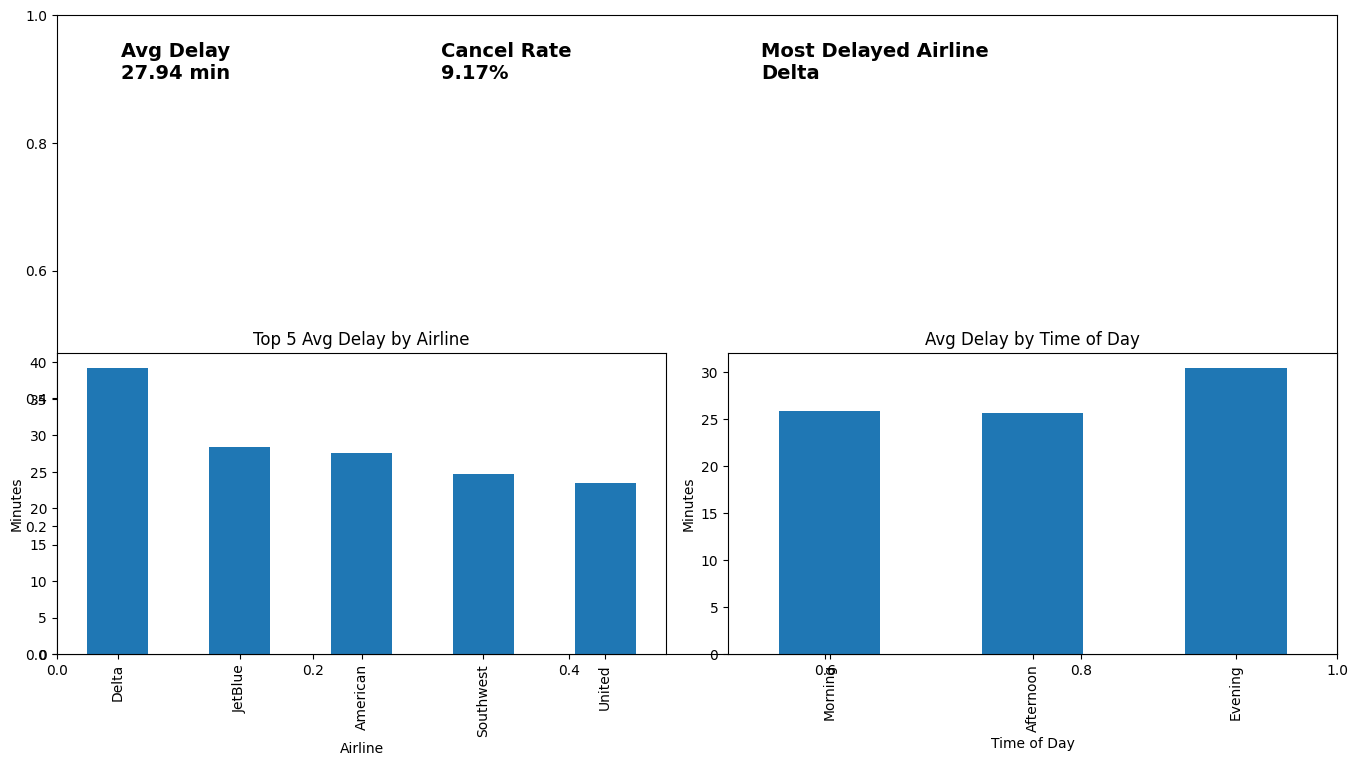

In [ ]:
plt.figure(figsize=(14, 8))

# KPI Section
plt.text(0.05, 0.9, f"Avg Delay\n{avg_delay} min", fontsize=14, weight='bold')
plt.text(0.30, 0.9, f"Cancel Rate\n{cancel_rate}%", fontsize=14, weight='bold')
plt.text(0.55, 0.9, f"Most Delayed Airline\n{most_delayed_airline}", fontsize=14, weight='bold')

# Chart 1
plt.subplot(2, 2, 3)
delay_by_airline.head(5).plot(kind='bar')
plt.title("Top 5 Avg Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Minutes")

# Chart 2
plt.subplot(2, 2, 4)
delay_by_time.plot(kind='bar')
plt.title("Avg Delay by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Minutes")

plt.tight_layout()
plt.show()

# Tampilkan rata-rata delay per-kategori

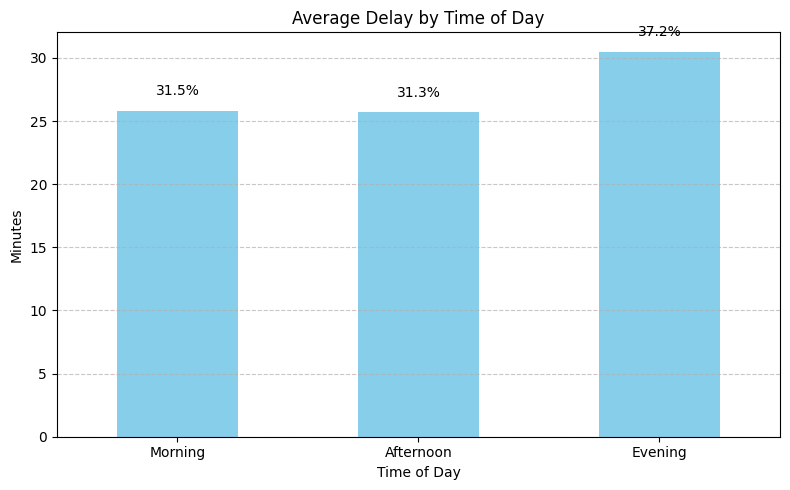

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
ax = delay_by_time.plot(kind='bar', color='skyblue')
plt.title("Average Delay by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Calculate percentages
total_delay = delay_by_time.sum()
percentages = (delay_by_time / total_delay) * 100

# Add percentage labels
for i, (val, perc) in enumerate(zip(delay_by_time, percentages)):
    ax.text(i, val + 1, f'{perc:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# INSIGHT & REKOMENDASI

In [ ]:
print("KEY INSIGHTS")
print("- Evening flights have the highest average delay")
print("- Delay varies significantly by airline")
print("- Low delay does not always mean low cancellation")

print("\nRECOMMENDATIONS")
print("- Optimize evening flight operations")
print("- Monitor high-delay airlines closely")
print("- Balance cancellation vs delay strategy")

KEY INSIGHTS
- Evening flights have the highest average delay
- Delay varies significantly by airline
- Low delay does not always mean low cancellation

RECOMMENDATIONS
- Optimize evening flight operations
- Monitor high-delay airlines closely
- Balance cancellation vs delay strategy


# WAWASAN UTAMA
- Penerbangan malam hari memiliki rata-rata keterlambatan tertinggi
- Keterlambatan sangat bervariasi tergantung maskapai penerbangan
- Keterlambatan rendah tidak selalu berarti pembatalan rendah

# REKOMENDASI
- Optimalkan operasional penerbangan malam hari
- Pantau maskapai penerbangan dengan keterlambatan tinggi secara cermat
- Seimbangkan strategi pembatalan dan penundaan

# Task
Analyze average flight departure delays by origin airport, destination airport, and day of the week, then visualize these findings using bar charts with proper titles and labels, and finally provide a summary of the insights gained regarding these additional delay factors.

## Analyze Delays by Origin Airport

### Subtask:
Calculate the average departure delay for each origin airport to identify which airports contribute most to delays.


**Reasoning**:
To calculate the average departure delay per origin airport, I need to group the `df_clean` DataFrame by the 'origin' column and then compute the mean of the 'departure_delay'. Finally, the results should be sorted in descending order to identify the airports with the highest delays.



In [ ]:
delay_by_origin = (
    df_clean.groupby('origin')['departure_delay']
    .mean()
    .sort_values(ascending=False)
)

print("Average Departure Delay by Origin Airport (Top 5):")
print(delay_by_origin.head())

Average Departure Delay by Origin Airport (Top 5):
origin
BOS    48.214286
JFK    37.777778
DEN    28.125000
SEA    26.875000
LAX    26.666667
Name: departure_delay, dtype: float64


# Task
## Analyze Delays by Destination Airport

### Subtask:
Calculate the average departure delay for each destination airport to identify if specific destinations are prone to delays.

**Reasoning**:
To calculate the average departure delay per destination airport, I need to group the `df_clean` DataFrame by the 'destination' column and then compute the mean of the 'departure_delay'. Finally, the results should be sorted in descending order to identify the destination airports with the highest delays.

## Analyze Delays by Destination Airport

### Subtask:
Calculate the average departure delay for each destination airport to identify if specific destinations are prone to delays.


**Reasoning**:
To analyze delays by destination airport, I will group the cleaned DataFrame by 'destination', calculate the mean of 'departure_delay', sort the results in descending order, and then print the top 5 destination airports with the highest average delays, as per the instructions.



In [ ]:
delay_by_destination = (
    df_clean.groupby('destination')['departure_delay']
    .mean()
    .sort_values(ascending=False)
)

print("Average Departure Delay by Destination Airport (Top 5):")
print(delay_by_destination.head())

Average Departure Delay by Destination Airport (Top 5):
destination
SFO    39.166667
BOS    36.111111
LAS    31.250000
ATL    30.333333
LAX    30.000000
Name: departure_delay, dtype: float64


## Analyze Delays by Day of Week

### Subtask:
Extract the day of the week from 'scheduled_departure' and calculate the average departure delay to understand if certain days have more delays.


**Reasoning**:
To analyze delays by day of the week, I will first ensure 'scheduled_departure' is in datetime format, then extract the day of the week, group the dataframe by this new column, and calculate the average 'departure_delay'. I will sort the results to display the days in order from Monday to Sunday.



In [ ]:
df_clean['scheduled_departure'] = pd.to_datetime(df_clean['scheduled_departure'])
df_clean['day_of_week'] = df_clean['scheduled_departure'].dt.day_name()

delay_by_day_of_week = (
    df_clean.groupby('day_of_week')['departure_delay']
    .mean()
)

# Define the desired order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reindex the Series to sort by day of week
delay_by_day_of_week = delay_by_day_of_week.reindex(day_order)

print("Average Departure Delay by Day of Week:")
print(delay_by_day_of_week)

Average Departure Delay by Day of Week:
day_of_week
Monday       19.230769
Tuesday      29.210526
Wednesday    43.636364
Thursday     25.454545
Friday       25.357143
Saturday     30.000000
Sunday       26.562500
Name: departure_delay, dtype: float64


**Reasoning**:
The subtask of calculating average departure delay by day of the week has been completed. Now, I need to visualize the average departure delay by origin airport using a bar chart as specified by the main task instructions to fulfill the visualization requirement.



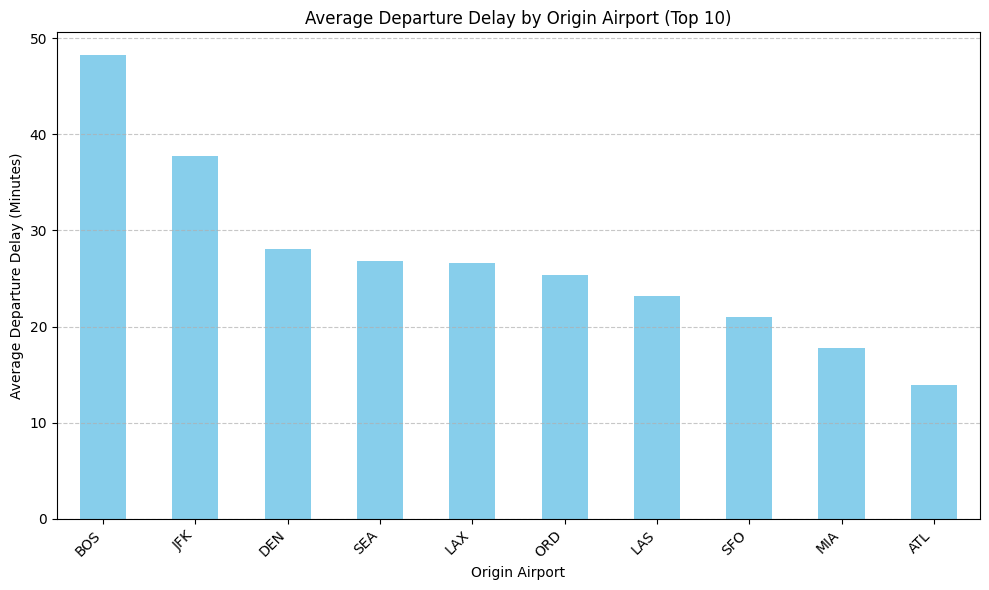

In [ ]:
plt.figure(figsize=(10, 6))
delay_by_origin.head(10).plot(kind='bar', color='skyblue')
plt.title('Average Departure Delay by Origin Airport (Top 10)')
plt.xlabel('Origin Airport')
plt.ylabel('Average Departure Delay (Minutes)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
Following the main task's visualization requirement, I will now create a bar chart to display the average departure delay by destination airport, using the pre-calculated `delay_by_destination` data. This will complete the visualization for the second factor.



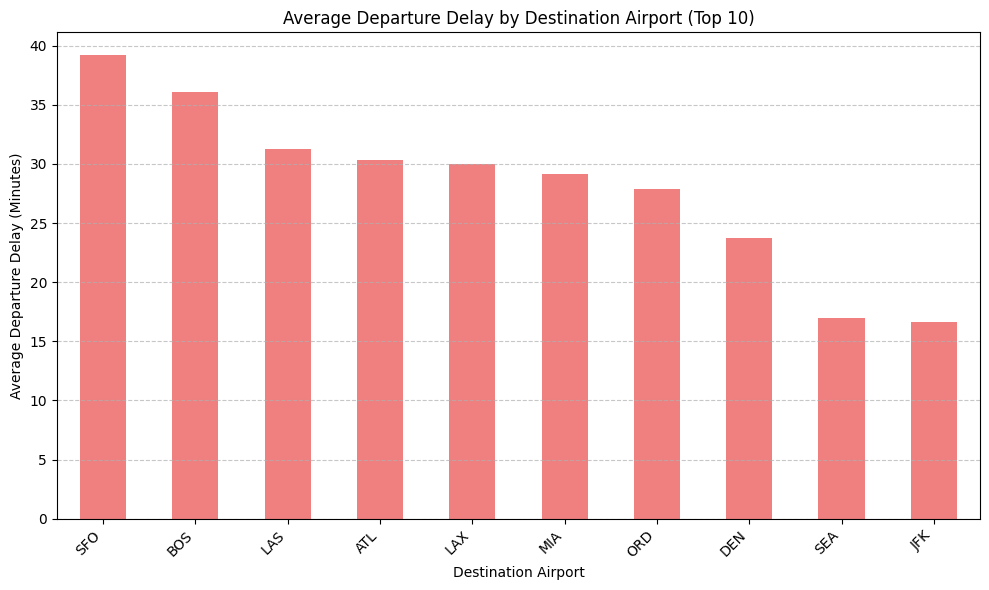

In [ ]:
plt.figure(figsize=(10, 6))
delay_by_destination.head(10).plot(kind='bar', color='lightcoral')
plt.title('Average Departure Delay by Destination Airport (Top 10)')
plt.xlabel('Destination Airport')
plt.ylabel('Average Departure Delay (Minutes)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The average departure delay by day of the week has been calculated. The next step is to visualize this data using a bar chart to fulfill the visualization requirement of the main task. This will complete all required visualizations before summarizing insights.



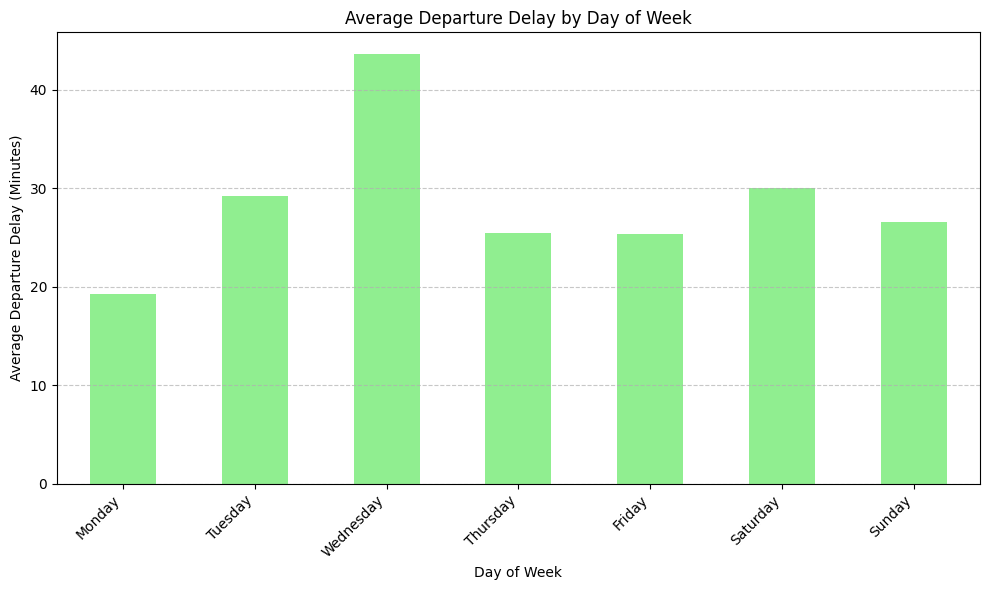

In [ ]:
plt.figure(figsize=(10, 6))
delay_by_day_of_week.plot(kind='bar', color='lightgreen')
plt.title('Average Departure Delay by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Departure Delay (Minutes)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Ringkasan Wawasan tentang Faktor Penundaan Tambahan

### Wawasan dari Penundaan Bandara Asal:
* **BOS (Boston) dan JFK (John F. Kennedy)** diidentifikasi sebagai bandara asal dengan penundaan keberangkatan rata-rata tertinggi, menunjukkan potensi hambatan operasional atau volume lalu lintas yang lebih tinggi di lokasi-lokasi ini.

* Terdapat variasi yang signifikan dalam penundaan rata-rata di berbagai bandara asal, menunjukkan bahwa masalah penundaan tidak terdistribusi secara merata dan mungkin terlokalisasi di hub tertentu.

### Wawasan dari Penundaan Bandara Tujuan:
* **SFO (San Francisco) dan BOS (Boston)** muncul sebagai tujuan utama yang mengalami penundaan keberangkatan rata-rata yang signifikan, yang dapat disebabkan oleh kemacetan kontrol lalu lintas udara, pola cuaca, atau infrastruktur bandara saat kedatangan.
* Penundaan di bandara tujuan mencerminkan tren serupa dengan bandara asal, menekankan bahwa kondisi keberangkatan dan kedatangan berkontribusi pada penundaan penerbangan secara keseluruhan.

### Wawasan dari Keterlambatan Berdasarkan Hari dalam Seminggu:
* **Rabu** menonjol sebagai hari dengan rata-rata keterlambatan keberangkatan tertinggi, menunjukkan bahwa perjalanan di pertengahan minggu mungkin sangat rentan terhadap keterlambatan.
* **Senin** umumnya menunjukkan rata-rata keterlambatan terendah, mungkin karena lalu lintas yang lebih ringan atau operasi yang lebih efisien di awal minggu.
* Keterlambatan juga menunjukkan fluktuasi sepanjang minggu, menunjukkan bahwa volume penumpang, tingkat staf, atau praktik operasional mungkin bervariasi setiap harinya.

## Ringkasan:

### Tanya Jawab
1. **Apakah bandara tujuan tertentu rentan terhadap keterlambatan?**

Ya, bandara tujuan tertentu rentan terhadap keterlambatan. SFO (San Francisco) memiliki rata-rata keterlambatan keberangkatan tertinggi yaitu 39,17 menit, diikuti oleh BOS (Boston) dengan 36,11 menit, LAS (Las Vegas) dengan 31,25 menit, ATL (Atlanta) dengan 30,33 menit, dan LAX (Los Angeles) dengan 30,00 menit.

2. **Apakah hari-hari tertentu dalam seminggu memiliki lebih banyak keterlambatan?**

Ya, hari-hari tertentu dalam seminggu mengalami rata-rata keterlambatan keberangkatan yang berbeda. Hari Rabu menonjol dengan rata-rata keterlambatan keberangkatan tertinggi yaitu 43,64 menit, sedangkan hari Senin memiliki rata-rata keterlambatan terendah yaitu 19,23 menit.

### Temuan Utama Analisis Data
* **Bandara Tujuan dengan Keterlambatan Tertinggi:** SFO memimpin dengan keterlambatan keberangkatan rata-rata 39,17 menit, diikuti oleh BOS (36,11 menit) dan LAS (31,25 menit).
* **Bandara Asal dengan Keterlambatan Tertinggi:** BOS (Boston) dan JFK (John F. Kennedy) diidentifikasi sebagai bandara asal dengan keterlambatan keberangkatan rata-rata tertinggi, yang menunjukkan potensi hambatan operasional.
* **Hari dalam Seminggu dengan Keterlambatan Tertinggi:** Hari Rabu mengalami keterlambatan keberangkatan rata-rata tertinggi yaitu 43,64 menit.
* **Hari dalam Seminggu dengan Keterlambatan Terendah:** Hari Senin memiliki keterlambatan keberangkatan rata-rata terendah, yaitu 19,23 menit.

### Wawasan atau Langkah Selanjutnya
* Investigasi lebih lanjut mengenai penyebab spesifik keterlambatan di bandara dengan tingkat keterlambatan tinggi (SFO, BOS, JFK) dan pada hari Rabu dapat mengungkap masalah mendasar seperti kemacetan kontrol lalu lintas udara, dampak cuaca, atau inefisiensi operasional.
* Variasi keterlambatan di berbagai hari dalam seminggu dan bandara menunjukkan peluang untuk mengoptimalkan jadwal penerbangan, alokasi sumber daya, atau manajemen lalu lintas udara untuk mengurangi keterlambatan pada hari-hari puncak dan di lokasi kemacetan.